In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

c:\Users\user\miniconda3\envs\Lab_Programmazione\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                country  beer_servings  spirit_servings  wine_servings  \
15              Belarus            142              373             42   
98            Lithuania            343              244             56   
3               Andorra            245              138            312   
68              Grenada            199              438             28   
61               France            127              151            370   
45       Czech Republic            361              170            134   
141  Russian Federation            247              326             73   
99           Luxembourg            236              133            271   
155            Slovakia            196              293            116   
81              Ireland            313              118            165   
75              Hungary            234              215            185   
65              Germany            346              117            175   
136            Portugal            194

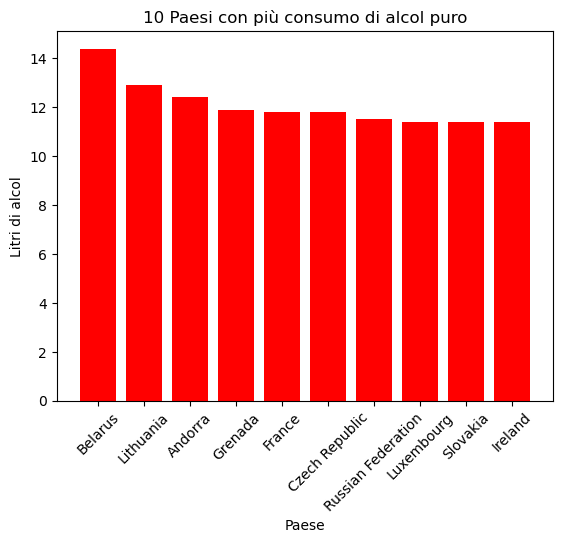

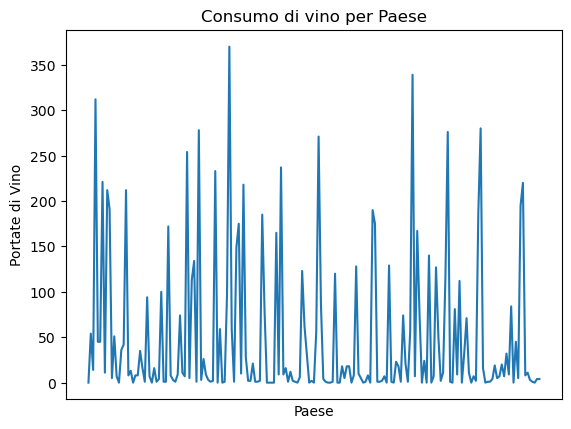

In [2]:
#esercizio 1

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")  #importo il dataset
df.head(4)  #visualizzo le prime quattro righe giusto per capire come è fatto

df_consumoAlcol=df.sort_values(by="total_litres_of_pure_alcohol", ascending=False) #ordino sulla base della colonna total_litres_of_pure_alcohol
print(df_consumoAlcol.head(50)) #visualizzo solo le prime 10 righe

media_birra=df["beer_servings"].mean()
media_vino=df["wine_servings"].mean()
media_distillati=df["spirit_servings"].mean()  #seleziono per colonna e applico la funzione mean()
print(f"media birra: {media_birra} , media vino: {media_vino} , media distillati: {media_distillati}") #visualizzo i risultati

df["alcohol_index"]=(df["beer_servings"] + df["wine_servings"] + df["spirit_servings"])/3 #sommmo le colonne e divido per 3 nella nuova colonna

print(df.sort_values(by="alcohol_index",ascending=False).head(1)["country"]) #visualizzo solo colui che ha il valore più alto nella colonna appena creata

paesi_above_100birre=df[df["beer_servings"]>100] #seleziono solo le righe che hanno il valore delle birre sopra 100
print(paesi_above_100birre)


plt.bar(df_consumoAlcol.head(10)['country'], df_consumoAlcol.head(10)['total_litres_of_pure_alcohol'], color='red') #creo un graifco con sulle x i Paesi e sulle y i litri totali
plt.title('10 Paesi con più consumo di alcol puro') #inserisco un titolo
plt.xlabel('Paese') #inserisco etichetta asse X
plt.ylabel('Litri di alcol') #inserisco etichetta asse Y
plt.xticks(rotation=45) #ruoto per questioni di spazio
plt.show() #mostro il grafico

df_paese_ordinato=df.sort_values(by="country")  #creo un df ordinando  per Paese in ordine alfabetico
plt.plot(df_paese_ordinato['country'], df_paese_ordinato['wine_servings']) #creo il grafico
plt.title('Consumo di vino per Paese') #inserisco un titolo
plt.xlabel('Paese') #inserisco etichetta asse X
plt.ylabel('Portate di Vino') #inserisco etichetta asse Y
plt.xticks([]) #nascondo i nomi dei Paesi, sono troppi per essere rappresentati sul grafico
plt.show()


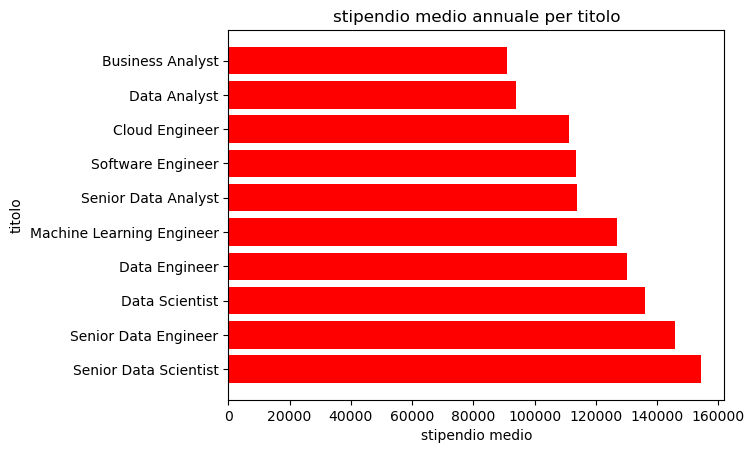

In [3]:
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

ls_paesi=df["job_country"].unique() #salvo una lista con i paesi non ripetuti
analisi_paesi=[]
for paese in ls_paesi:
    df_filtrato=df[df["job_country"]==paese]  #filtro il data frame
    stipendio_medio=df_filtrato["salary_year_avg"].mean()
    job_count=len(df_filtrato)
    stipendio_max=df_filtrato["salary_year_avg"].max()
    stipendio_min=df_filtrato["salary_year_avg"].min()  #eseguo le richieste
    analisi_paesi.append([paese,stipendio_medio,job_count,stipendio_max,stipendio_min]) #aggiungo alla lista

ls_titoli = df["job_title_short"].unique() #lista con i titoli non ripetuti
analisi_titoli=[]
for titolo in ls_titoli:
    df_titolo = df[df["job_title_short"] == titolo]  #filtro il data frame
    stipendio_medio = df_titolo["salary_year_avg"].mean()
    if not pd.isna(stipendio_medio):
        analisi_titoli.append([titolo, stipendio_medio])  #controlo con sia un valore valido

df_grafico = pd.DataFrame(analisi_titoli, columns=["titolo", "stipendio_medio"])
df_grafico = df_grafico.sort_values(by="stipendio_medio", ascending=False) #ordino il df_grafico
plt.barh(df_grafico["titolo"], df_grafico['stipendio_medio'], color="red") #creo il grafico
plt.title("stipendio medio annuale per titolo")
plt.xlabel("stipendio medio")
plt.ylabel("titolo")
plt.show()


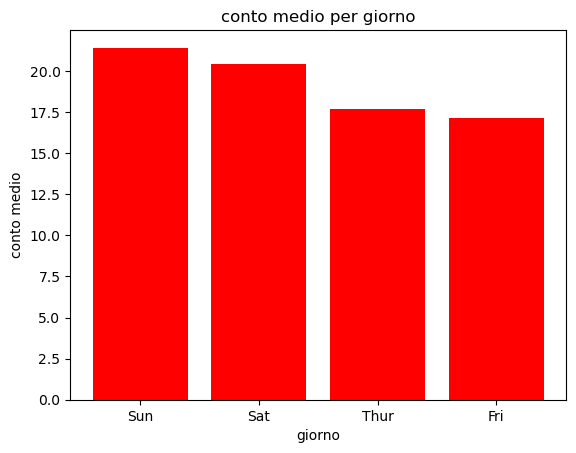

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

analisi_giornaliera=[]
ls_giorni=df["day"].unique()   #salvo i giorni in una lista
df["conto_per_persona"]=df["total_bill"]/df["size"]
for giorno in ls_giorni:
    df_filtrato=df[df["day"]==giorno]
    conto_medio=df_filtrato["total_bill"].mean()
    osservazioni=len(df_filtrato)
    conto_minimo=df_filtrato["total_bill"].min()
    conto_massimo=df_filtrato["total_bill"].max()  #eseguo le operazioni richieste
    analisi_giornaliera.append([giorno,conto_medio,osservazioni,conto_minimo,conto_massimo])
df_aux=pd.DataFrame(analisi_giornaliera,columns=["giorno","conto_medio","osservazioni","conto_minimo","conto_massimo"]) #creo un data frame ausiliario
df_ordinato=df_aux.sort_values(by=["conto_medio"],ascending=False) #ordino il data frame ausiliario
giorno_conto_medio_max=df_ordinato["giorno"].iloc[0]  #prendo solo il giorno

df_grafico = pd.DataFrame(analisi_giornaliera, columns=["giorno","conto_medio","osservazioni","conto_minimo","conto_massimo"])
df_grafico = df_grafico.sort_values(by="conto_medio", ascending=False)
plt.bar(df_grafico["giorno"],df_grafico["conto_medio"],color="red")
plt.xlabel("giorno")
plt.ylabel("conto medio")
plt.title("conto medio per giorno")
plt.show()
